# Bike Availability Forecasting

This notebook is just making a naive forecasting based on the average of the data.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
# Tensor decomposition
from tensorly.decomposition import tucker

from utilities import To_Numpy, concat_features

np.random.seed(42)

LOAD DATA

In [2]:
# Load dataset
ds = xr.open_dataset("../full_db.nc")
ds["bike"] = ds["vm_disp"] + ds["vae_disp"]

TIME CONFIGURATION

In [3]:
# First Monday of 2023 (dataset starts on a Sunday)
first_monday_index = 24

n_stations = len(ds["station"])

n_time_full = len(ds["time"]) - first_monday_index

n_weeks = n_time_full // (7 * 24)

n_time = 24 * 7 * n_weeks
n_days = 7 * n_weeks

# ---------------------------------------------------------
# Static covariates
# ---------------------------------------------------------
#memory efficiency
float_tp = np.float32
#Xarray -> Numpy
to_numpy = To_Numpy(ds, first_monday_index, n_weeks, float_tp)

#/!\ a few station capacity are negative due to a preprocessing bug
capacity = np.positive(to_numpy("capacite"))

lat = to_numpy("latitude")
lon = to_numpy("longitude")
#print(lat.shape, lon.shape)
Meteo = to_numpy("meteo_h")
Holiday = to_numpy("feries")
#print(Meteo.shape, Holiday.shape)
#print(Meteo[:2,:2])
#print(Holiday[:2,:2])

IMPORTANT: EMBEDDING FUNCTION (with Tucker)

In [4]:
rank = [10, n_weeks, 7, 10]

def tensor_encoding(x):
    """
    Extract spatial and temporal embeddings using Tucker decomposition.

    Dimensions:print(rmse_scores.shape)
    station × week × day × hour
    """

    _, factors = tucker(
        x.reshape(n_stations, n_weeks, 7, 24).astype(np.float32),
        rank=rank
    )

    spatial_encoding = (factors[0] / (capacity[:, None] + 0.01))
    spatial_features = concat_features([capacity[:, None], spatial_encoding]).astype(float_tp)

    day_encoding = factors[2]
    hour_encoding = factors[3]

    time_encoding = concat_features(
        [day_encoding[:, None, :], hour_encoding[None, :, :]],
        shape=[7, 24],
        flatten=True
    )
    temporal_features = time_encoding.astype(float_tp)

    return spatial_features, temporal_features

In [5]:
def prepare_data(variable):
    """
    Prepare base tensors and embeddings for a given variable.
    """

    Y = to_numpy(variable)

    spatial_features, temporal_features = tensor_encoding(Y)

    spatial_features = np.concatenate(
        [spatial_features, lat[:, None], lon[:, None]],
        axis=1
    )

    return {
        "Y": Y,
        "space": spatial_features,
        "time": temporal_features
    }

PREPARE DATA FOR REGRESSION TASK

In [6]:
#prepare target embedding (Tucker)
data_dict = prepare_data("bike")

In [7]:
def in_week_end(t):
    return np.isin(t // 24, [5, 6])


def rmse(y, pred):
    return np.sqrt(np.mean((y - pred)**2, axis=(0)))

def pred_for_time(T, Y_prev):
    n_stations, n_weeks, n_hours = Y_prev.shape

    # Create a mask for weekend hours (shape: (168,))
    hour_mask = in_week_end(np.arange(n_hours))

    # Split into weekend and weekday hours
    Y_weekend = Y_prev[:, :, hour_mask]  # Shape: (n_stations, n_weeks, 48)
    Y_weekday = Y_prev[:, :, ~hour_mask]  # Shape: (n_stations, n_weeks, 120)

    # Extract the last T weeks for all stations and hours
    Y_last_T_wk = Y_weekend[:, -T-1:-1, :]  # Shape: (n_stations, T, n_hours)
    Y_last_T_wd = Y_weekday[:, -T-1:-1, :]  # Shape: (n_stations, T, n_hours)

    # Compute mean predictions for weekend and weekday hours
    weekend_preds = np.mean(Y_last_T_wk, axis=1)  # Shape: (n_stations, 48)
    weekday_preds = np.mean(Y_last_T_wd, axis=1)  # Shape: (n_stations, 120)

    # Initialize predictions array
    preds = np.zeros((n_stations, n_hours))

    # Assign predictions for weekend and weekday hours
    preds[:, hour_mask] = weekend_preds
    preds[:, ~hour_mask] = weekday_preds

    return preds, weekday_preds, weekend_preds, Y_weekend, Y_weekday

In [8]:
def preds_for_all_weeks(T, Y):
    n_stations, n_weeks, n_hours = Y.shape
    pred_all_weeks = np.zeros((n_stations, n_weeks-(T+1), n_hours))
    pred_wk_all_weeks = np.zeros((n_stations, n_weeks-(T+1), 2*n_hours//7))
    pred_wd_all_weeks = np.zeros((n_stations, n_weeks-(T+1), 5*n_hours//7))


    # Loop over each week and compute predictions
    for week in range(T+1, n_weeks):
        preds, weekday_preds, weekend_preds, Y_weekend, Y_weekday = pred_for_time(T, Y[:, :week+1, :])
        pred_all_weeks[:, week-(T+1), :] = preds
        pred_wk_all_weeks[:, week-(T+1), :] = weekend_preds
        pred_wd_all_weeks[:, week-(T+1), :] = weekday_preds     

    return pred_all_weeks, pred_wd_all_weeks, pred_wk_all_weeks, Y_weekend, Y_weekday

In [9]:
from scipy.ndimage import gaussian_filter1d

def plot_rmse_smooth(pred, data, T):
    #sigma=int(T/2+5)
    sigma=data.shape[2]//4
    data=data[:, -(n_weeks-(T+1)):, :]
    rmse_scores = rmse(data, pred)

    flat_rmse=rmse_scores.flatten()
    flat_pred=np.mean(pred, axis=0).flatten()
    flat_data=np.mean(data, axis=0).flatten()

    smoothed_rmse = gaussian_filter1d(flat_rmse, sigma=sigma)
    smoothed_pred = gaussian_filter1d(flat_pred, sigma=sigma)
    smoothed_data = gaussian_filter1d(flat_data, sigma=sigma)

    plt.figure(figsize=(12, 6))
    
    plt.plot(smoothed_pred, linewidth=2, label='smoothed pred')
    plt.plot(smoothed_data, linewidth=2, label='smoothed data')
    plt.plot(smoothed_rmse, linewidth=2, label='Smoothed RMSE')
    plt.plot(flat_pred, alpha=0.5, linewidth=0.5, label='Raw pred')
    plt.plot(flat_data, alpha=0.5, linewidth=0.5, label='Raw data')
    plt.plot(flat_rmse, alpha=0.7, linewidth=0.5, label='Raw RMSE')

    plt.xlabel('Hours')
    plt.ylabel('Bikes')
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
Y = to_numpy("bike")
T = 8
pred_all_weeks, weekday_preds_awks, weekend_preds_awks, Y_weekend, Y_weekday = preds_for_all_weeks(T, Y)

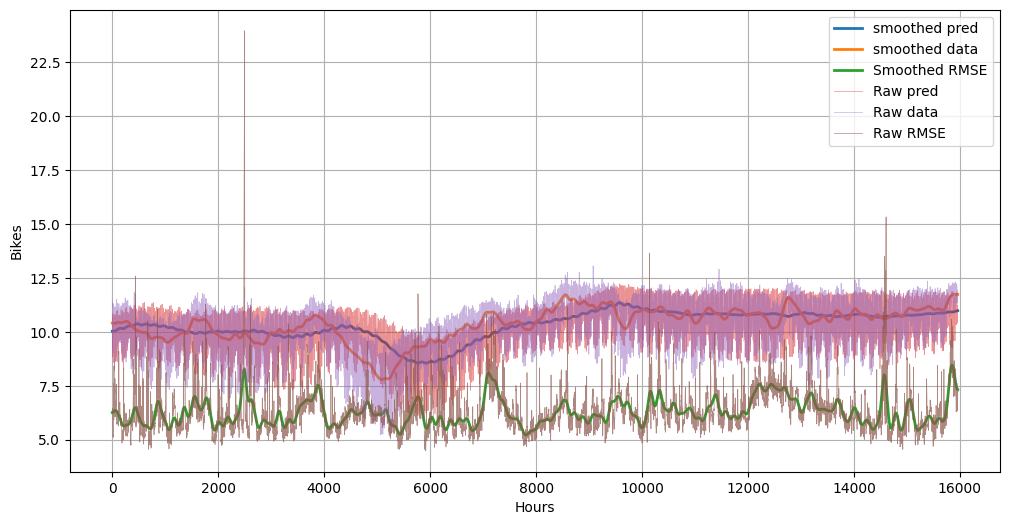

In [14]:
plot_rmse_smooth(pred_all_weeks, Y, T)

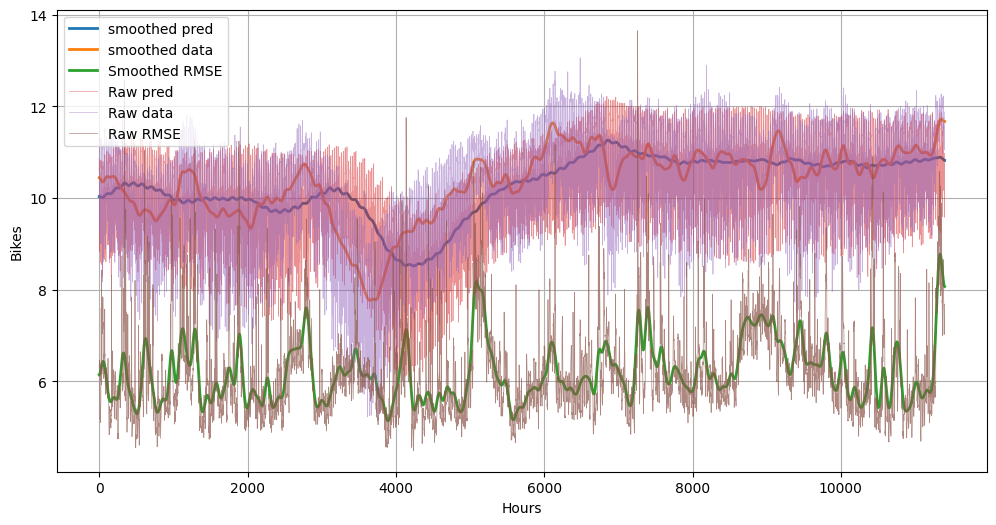

In [13]:
plot_rmse_smooth(weekday_preds_awks, Y_weekday, T)

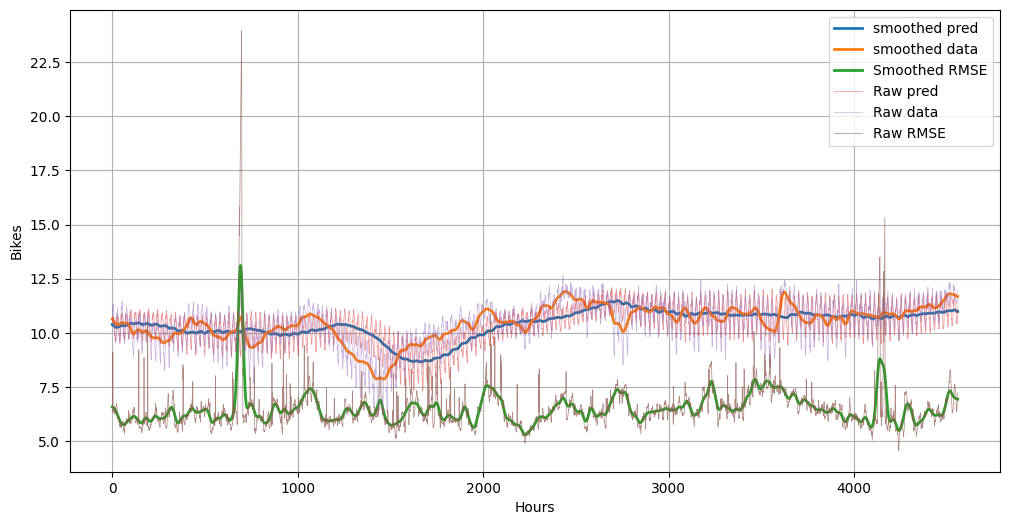

In [15]:
plot_rmse_smooth(weekend_preds_awks, Y_weekend, T)

In [ ]:
def comp_glob_rmse(T_range, Y):
    glob_rmse = []
    for T in T_range:
        predss, _, _, _, _ = preds_for_all_weeks(T, Y)
        se = (Y[:, -(n_weeks-(T+1)):, :]- predss)**2
        mse = np.mean(se)
        comp_rmse = np.sqrt(mse)
        glob_rmse.append(comp_rmse)
    print(glob_rmse)
    return np.array(glob_rmse)



[np.float64(7.699443516855187), np.float64(6.86293882963677), np.float64(6.583750743795658), np.float64(6.462917495044474), np.float64(6.398587775097248), np.float64(6.375906487622715), np.float64(6.365953779065939), np.float64(6.351603924901338), np.float64(6.348144015888195), np.float64(6.353207639609541), np.float64(6.3504818528115985), np.float64(6.362487388681527), np.float64(6.375778469677785), np.float64(6.383456765417759), np.float64(6.403295194979679), np.float64(6.423498344507572), np.float64(6.436917153907972), np.float64(6.440572551495355), np.float64(6.448429065645166)]


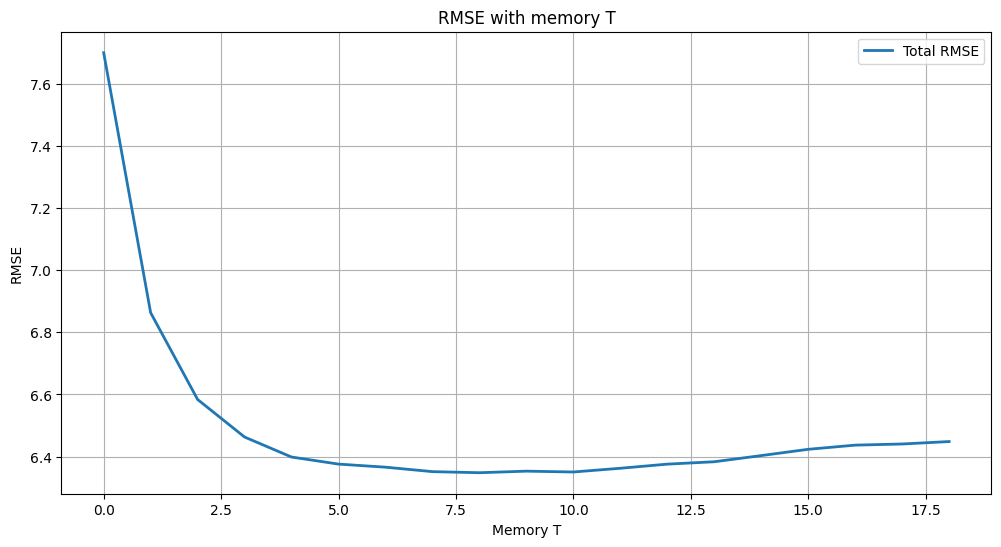

In [ ]:
glob_rmse = comp_glob_rmse(range(1,20),Y)
plt.figure(figsize=(12, 6))

plt.plot(glob_rmse, linewidth=2, label=f'Total RMSE')
plt.xlabel('Memory T')
plt.ylabel('RMSE')
plt.title('RMSE with memory T')
plt.legend()
plt.grid(True)
plt.show()